# 🏃 Visualising Off-Ball Runs for a Single Match

This notebook demonstrates how to retrieve and visualise **off-ball run** dynamic events for a specific match using the open-data CSV files (or the SkillCorner API) and the `mplsoccer` pitch library.

Each off-ball run is drawn as a directional arrow on a half-pitch map, colour-coded by run type and intensity:
- **Run subtype** (e.g. `cross_receiver`) drives the base colour
- **Speed band** (e.g. `hsr` = High Speed Running) overrides the colour with a highlight
- **Received runs** are connected back to the passer's end position with a dashed line
- **Runs that led to a goal** are further highlighted with a large circle marker

## 📋 Step 1: Setup & Prerequisites
- Python installed
- Required libraries: `numpy`, `pandas`, `mplsoccer`, `skillcorner`, `skillcornerviz`
```bash
pip install numpy pandas mplsoccer skillcorner skillcornerviz
```
- A valid SkillCorner username and password stored as environment variables:
  - `SKILLCORNER_USERNAME`
  - `SKILLCORNER_PASSWORD`
We import all the required libraries:
- `pandas` and `io` for data loading
- `SkillcornerClient` for optional API access (commented out by default)
- `VerticalPitch` from `mplsoccer` for pitch rendering
- `constants` from `skillcornerviz` for the official SkillCorner colour palette

In [1]:
import os
import io
import pandas as pd
from skillcorner.client import SkillcornerClient
from mplsoccer import VerticalPitch
from skillcornerviz.utils import constants

/Users/nano/PycharmProjects/opendata/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 🔐 Step 2: Authenticate & Configure

We read credentials from environment variables (never hardcode credentials in notebooks).
Set the `match_id` to the game you want to analyse.

You can find available match IDs in the `data/matches/` directory of this repository.

In [2]:
# --- Configuration ---
match_id = 1886347  # Change this to the match you want to visualise

# Read credentials from environment variables
username = os.environ.get("SKILLCORNER_USERNAME")
password = os.environ.get("SKILLCORNER_PASSWORD")

# Instantiate the SkillCorner API client
client = SkillcornerClient(username=username, password=password)

## 📥 Step 3: Load Off-Ball Runs Data

We load off-ball run events from the open-data CSV file bundled in this repository.
The file `{match_id}_dynamic_events.csv` contains all dynamic event types; we filter to `event_type == 'off_ball_run'`.

The resulting `events_df` contains one row per off-ball run, with columns describing:
- Spatial info: `x_start`, `y_start`, `x_end`, `y_end` — start and end positions of the run
- Run metadata: `event_subtype` (run type), `speed_avg_band` (intensity), `received`, `lead_to_goal`
- Passer position: `player_in_possession_x_end`, `player_in_possession_y_end` — where the passer was when the pass was made

> **API alternative:** If you have SkillCorner API credentials, you can replace the CSV load with:
> ```python
> raw_bytes = client.get_dynamic_events_off_ball_runs(match_id)
> events_df = pd.read_csv(io.BytesIO(raw_bytes))
> ```

In [3]:
####-----------------------------------------------------------------------------------
# Load from local open-data CSV (default)
####-----------------------------------------------------------------------------------
raw_df = pd.read_csv(f"../../data/matches/{match_id}/{match_id}_dynamic_events.csv")

# Filter to off-ball run events only
events_df = raw_df[raw_df["event_type"] == "off_ball_run"].reset_index(drop=True)

####-----------------------------------------------------------------------------------
# API alternative (requires SkillCorner credentials)
####-----------------------------------------------------------------------------------
# raw_bytes = client.get_dynamic_events_off_ball_runs(match_id)
# events_df = pd.read_csv(io.BytesIO(raw_bytes))

print(f"Loaded {len(events_df)} off-ball run events")
events_df.head()

Loaded 599 off-ball run events


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
0,1_0,10,1886347,74,90,NaN,00:06.4,00:08.0,0,6,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN
1,1_1,12,1886347,81,96,NaN,00:07.1,00:08.6,0,7,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN
2,1_2,13,1886347,82,99,NaN,00:07.2,00:08.9,0,7,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN
3,1_3,16,1886347,207,217,NaN,00:19.7,00:20.7,0,19,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,NaN
4,1_4,29,1886347,300,309,NaN,00:29.0,00:29.9,0,29,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN


## 🔍 Step 4: Filter Runs to Visualise

We create a `viz` view of the data to control which runs appear on the pitch map.

Common filters you might want to apply:
- Filter to a **specific player** by `player_id` or `player_name`
- Filter to a **specific run type** using `event_subtype` (e.g. `'runs_in_behind'`, `'cross_receiver'`)
- Filter to only **received runs** using the `received` column

By default we visualise all runs in the match.

In [11]:
# --- Filtering (customise as needed) ---

# Option A: Show all runs
# viz = events_df.copy()

# Option B: Filter to a specific player (uncomment and set player_id)
viz = events_df[events_df['player_id'] == 965685].copy()

# Option C: Filter to a specific run type (uncomment and set subtype)
# viz = events_df[events_df['event_subtype'] == 'runs_in_behind'].copy()

print(f"Visualising {len(viz)} runs")

Visualising 47 runs


## 🎨  Step 5: Visualise Off-Ball Runs on a Pitch Map

We use `mplsoccer`'s `VerticalPitch` to draw a half-pitch (attacking half only, via `half=True`).
The pitch dimensions are set to the standard 105×68 metre SkillCorner coordinate system.

**Colour logic for each run:**
1. Runs start as **dark** (text colour) by default.
2. If `event_subtype == 'cross_receiver'`, the run is coloured **secondary highlight** (green).
3. If `speed_avg_band == 'hsr'` (High Speed Running), the run is overridden to **primary highlight** (bright green). Sprint is typically the most intense band.

**Visual elements drawn per run:**
- A **wedge arrow** from `(y_end, x_end)` pointing to `(y_start, x_start)` — the direction of travel  
  *(Note: SkillCorner coordinates use x=length axis and y=width axis; `VerticalPitch` swaps these)*
- A small **dot** at the end position of the run
- If the run was **received**: a dashed line connecting the passer's end position to the runner's end position, plus a white circle at the passer's location
- If the run **led to a goal**: a large white circle at the runner's end position

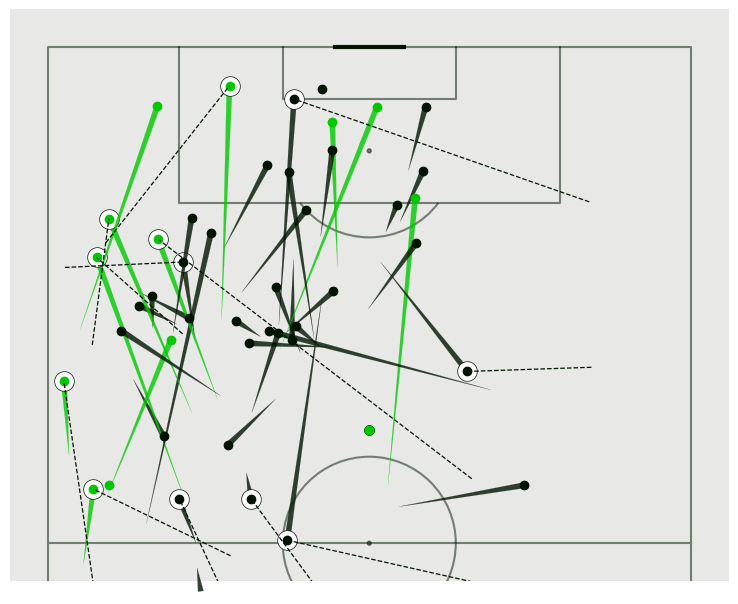

In [19]:
# --- Set up the pitch ---
pitch = VerticalPitch(
    pitch_type='skillcorner',
    line_alpha=0.5,
    pitch_length=105,
    pitch_width=68,
    half=True,                            # Only show attacking half
    pitch_color='#e8e8e6',
    line_color=constants.TEXT_COLOR,
    linewidth=1.5
)

fig, ax = pitch.grid(figheight=8, endnote_height=0, title_height=0)

# --- Draw each off-ball run ---
for i, row in viz.iterrows():

    # Highlight a particular run type
    if row['event_subtype'] == 'in_behind':  # RUNS OF THAT TYPE GET A SPECIFIC COLOR
        line_color = constants.SECONDARY_HIGHLIGHT_COLOR
    else:
        line_color = constants.TEXT_COLOR           # ALL OTHER TYPES REMAIN

    # Highlight a speed band
    # Speed bands: 'running' < 'hsr' < 'sprint'
    if row['speed_avg_band'] == 'hsr':
        line_color = constants.PRIMARY_HIGHLIGHT_COLOR

    # Draw the run
    # xy = arrowhead (start of run), xytext = arrow tail (end of run)
    # Note: VerticalPitch expects (y, x) because the pitch is rotated 90°
    ax.annotate(
        text='',
        xy=(row['y_start'], row['x_start']),         # Arrowhead at run start
        xytext=(row['y_end'], row['x_end']),          # Tail at run end
        arrowprops=dict(
            arrowstyle="wedge,shrink_factor=0.5,tail_width=0.4",
            facecolor=line_color,
            edgecolor=line_color,
            lw=0.1,
            alpha=0.8
        ),
        zorder=1
    )

    # Draw a small dot at the end position of the run
    ax.plot(row['y_end'], row['x_end'], 12, marker='o', color=line_color)

    # Show received runs
    if True: # Change this to True if you want to show reception
        if row['received'] == True:
            ax.scatter(
                row['y_end'],
                row['x_end'],
                c='white',
                edgecolor=constants.TEXT_COLOR,
                alpha=1,
                lw=0.5,
                s=200
            )
            ax.plot(
                [row['player_in_possession_y_end'], row['y_end']],
                [row['player_in_possession_x_end'], row['x_end']],
                c=constants.TEXT_COLOR,
                lw=0.9,
                alpha=1,
                ls='--'
            )

## 💡 Next Steps & Customisation Tips

- **Filter by run intensity**: Change the `speed_avg_band` condition to `'sprint'` to highlight only the most explosive runs
- **Filter by run subtype**: Use `event_subtype` values from `constants.RUN_TYPES` to focus on a single category (e.g. `'runs_in_behind'`)
- **Player-level view**: Filter `viz` to a single `player_id` to generate a per-player run map
- **Add a title**: Use `ax['title'].text(0.5, 0.5, 'Your Title Here', ...)` to annotate the chart
- **Save the figure**: Use `fig.savefig('off_ball_runs.png', dpi=150, bbox_inches='tight')`